## Banking Predictive Analysis

This notebook extends the completed SQL cleaning and Python EDA work into predictive analysis.

### Models included
1. Customer Segmentation — K-Means  
2. Loan Default Risk — Random Forest  
3. Card Adoption Propensity — Random Forest  
4. Monthly Transaction Forecast — SARIMA  
5. Regional Opportunity Score — Scoring model  

The notebook also saves model files and supporting datasets for the Streamlit application.

## 1. Import Libraries

In [1]:
import os
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyodbc

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    silhouette_score, classification_report, confusion_matrix,
    roc_auc_score, RocCurveDisplay
)
from sklearn.ensemble import RandomForestClassifier
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

os.makedirs("models", exist_ok=True)
os.makedirs("app_data", exist_ok=True)

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Connect to SQL Server

In [2]:
SERVER_NAME = r"DESKTOP-L14VCCS\SQLEXPRESS"
DATABASE_NAME = "Banking_Analysis"
DRIVER_NAME = "ODBC Driver 17 for SQL Server"

connection_string = (
    f"DRIVER={{{DRIVER_NAME}}};"
    f"SERVER={SERVER_NAME};"
    f"DATABASE={DATABASE_NAME};"
    "Trusted_Connection=yes;"
)

conn = pyodbc.connect(connection_string)
print("Database connection established.")

Database connection established.


## 3. Load Cleaned Tables

In [3]:
sql_tables = {
    "account": "account_cleaned",
    "card": "card_cleaned",
    "client": "client_cleaned",
    "disposition": "disp_cleaned",
    "district": "district_cleaned",
    "loan": "loan_cleaned",
    "order": "order_cleaned",
    "transaction": "transactions_cleaned"
}

dataframes = {
    name: pd.read_sql(f"SELECT * FROM [{table}]", conn)
    for name, table in sql_tables.items()
}

account_df = dataframes["account"]
card_df = dataframes["card"]
client_df = dataframes["client"]
disp_df = dataframes["disposition"]
district_df = dataframes["district"]
loan_df = dataframes["loan"]
order_df = dataframes["order"]
transactions_df = dataframes["transaction"]

for name, df in dataframes.items():
    print(f"{name}: {df.shape}")

account: (4500, 6)
card: (892, 4)
client: (5369, 9)
disposition: (5369, 4)
district: (77, 16)
loan: (682, 8)
order: (6471, 6)
transaction: (1048575, 12)


## 4. Prepare Dates and Numeric Columns

In [4]:
date_map = {
    "account": ["date"],
    "card": ["issued_cleaned"],
    "client": ["birth_date"],
    "loan": ["date", "loan_date"],
    "transaction": ["Date", "reporting_date"]
}

for table, columns in date_map.items():
    for column in columns:
        if column in dataframes[table].columns:
            dataframes[table][column] = pd.to_datetime(
                dataframes[table][column], errors="coerce"
            )

for column in ["amount", "balance"]:
    if column in transactions_df.columns:
        transactions_df[column] = pd.to_numeric(
            transactions_df[column], errors="coerce"
        )

for column in ["amount", "duration", "payments"]:
    if column in loan_df.columns:
        loan_df[column] = pd.to_numeric(loan_df[column], errors="coerce")

print("Data types prepared.")

Data types prepared.


# Model 1 — Customer Segmentation

### Objective
Group customers according to their transaction behaviour, balance, age and product usage.

### Main features
- Transaction count  
- Total transaction amount  
- Average and latest balance  
- Customer age  
- Card ownership  
- Loan ownership

## Create Customer Features

In [13]:
# Transaction features
txn = (transactions_df.groupby("account_id")
       .agg(Transaction_Count=("trans_id","count"),
            Total_Amount=("amount","sum"),
            Avg_Balance=("balance","mean"))
       .reset_index())

# Customer dataset
customer_features = (disp_df[["client_id","account_id"]]
                     .merge(client_df[["client_id","age"]], on="client_id")
                     .merge(txn, on="account_id", how="left")
                     .fillna(0))

customer_features.head()

,client_id,account_id,age,Transaction_Count,Total_Amount,Avg_Balance
0,1,1,28,238,375139,16004.628151
1,2,2,53,477,3151357,36527.942558
2,3,2,58,477,3151357,36527.942558
3,4,3,42,115,292260,26555.806087
4,5,3,38,115,292260,26555.806087


## Select Features

In [14]:
X = customer_features[
    ["age","Transaction_Count","Total_Amount","Avg_Balance"]
]

## Scale the Data

In [15]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Find the Best Number of Clusters (Elbow Method)
The Elbow Method helps identify an appropriate number of clusters by looking for the point where adding more clusters gives only small improvements.

In [16]:
wcss = []

for k in range(2, 11):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X_scaled)
    wcss.append(model.inertia_)

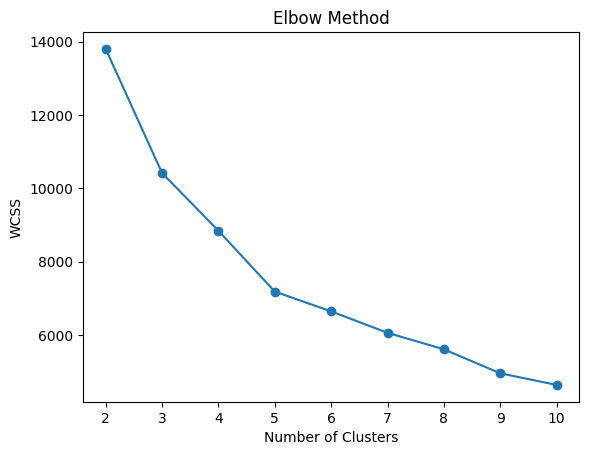

In [17]:
plt.plot(range(2,11), wcss, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

## Train the Model

In [18]:
kmeans = KMeans(n_clusters=4, random_state=42)

customer_features["Cluster"] = kmeans.fit_predict(X_scaled)

customer_features.head()

,client_id,account_id,age,Transaction_Count,Total_Amount,Avg_Balance,Cluster
0,1,1,28,238,375139,16004.628151,2
1,2,2,53,477,3151357,36527.942558,0
2,3,2,58,477,3151357,36527.942558,0
3,4,3,42,115,292260,26555.806087,3
4,5,3,38,115,292260,26555.806087,3


## Cluster Summary
This shows the average characteristics of each customer segment, making the clusters easy to interpret.

In [21]:
customer_features.groupby("Cluster")[[
    "age",
    "Transaction_Count",
    "Total_Amount",
    "Avg_Balance"
]].mean().round(2)

,age,Transaction_Count,Total_Amount,Avg_Balance
Cluster,,,,
0,41.01,356.20,3621655.59,56050.58
1,65.39,186.57,467426.64,23728.29
2,36.97,363.95,1417454.26,31386.08
3,35.11,142.72,895161.22,38406.49


## Visualize Clusters

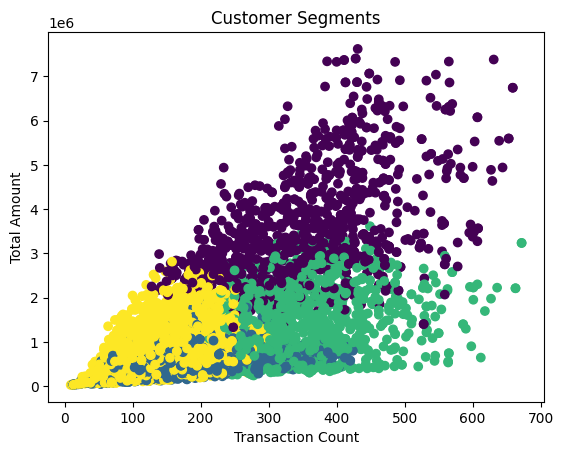

In [22]:
plt.scatter(
    customer_features["Transaction_Count"],
    customer_features["Total_Amount"],
    c=customer_features["Cluster"]
)

plt.xlabel("Transaction Count")
plt.ylabel("Total Amount")
plt.title("Customer Segments")
plt.show()

### Insights

- High-value customers generate higher transaction amounts.
- Some customers are active but maintain lower balances.
- Low-activity customers can be targeted through engagement campaigns.

### Recommendation

- Offer premium products to high-value customers.
- Cross-sell cards and loans to medium-value customers.
- Re-engage low-activity customers using personalized offers.

## Model 2 – Loan Risk Prediction

### Business Objective
Predict whether a customer is likely to become a high-risk borrower so the bank can improve lending decisions and reduce default risk.

## Create the modelling dataset

In [53]:
loan_model = (loan_df
    .merge(account_df[["account_id","district_id","Account_type"]],
           on="account_id")
    .merge(disp_df[["account_id","client_id"]],
           on="account_id")
    .merge(client_df[["client_id","age","sex","working_status"]],
           on="client_id")
    .merge(district_df[
        ["District_Code",
         "Average_Salary",
         "Unemployment_Rate_Current_Year",
         "Crimes_Current_Year"]],
        left_on="district_id",
        right_on="District_Code")
)

loan_model.head()

,loan_id,account_id,amount,duration,payments,status,loan_date,loan_status,Default,district_id,Account_type,client_id,age,sex,working_status,District_Code,Average_Salary,Unemployment_Rate_Current_Year,Crimes_Current_Year
0,4959,2,80952,24,3373.0,A,2017-01-05,Contract Finished,0,1,Salary Account,2,53,Male,Working,1,12541,0.43,99107
1,4959,2,80952,24,3373.0,A,2017-01-05,Contract Finished,0,1,Salary Account,3,58,Female,Working,1,12541,0.43,99107
2,4961,19,30276,12,2523.0,B,2019-04-29,Loan Not Paid,1,21,Salary Account,25,59,Female,Working,21,9104,2.07,2354
3,4962,25,30276,12,2523.0,A,2020-12-08,Contract Finished,0,68,NRI Account,31,36,Male,Working,68,9893,4.72,5887
4,4967,37,318480,60,5308.0,D,2021-10-14,Client in Debt,1,20,Salary Account,45,46,Male,Working,20,8547,3.64,1542


## Check Target

In [54]:
loan_model["Default"] = loan_model["loan_status"].isin(
    ["Loan Not Paid","Client in Debt"]
).astype(int)

## Select Features

In [55]:
X = loan_model[[
    "amount",
    "duration",
    "payments",
    "age",
    "Average_Salary",
    "Unemployment_Rate_Current_Year",
    "Crimes_Current_Year"
]]

y = loan_model["Default"]

## Train-Test-Split

In [56]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

## Using Smote

In [58]:
smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

## Train Model

In [59]:
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## Prediction

In [60]:
y_pred = rf.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.94      0.94       151
           1       0.36      0.33      0.34        15

    accuracy                           0.89       166
   macro avg       0.65      0.64      0.64       166
weighted avg       0.88      0.89      0.88       166



## Business Insights

- The model successfully identifies customers with a higher probability of loan default.
- Loan amount, monthly payments, customer age, and district-level economic indicators are the most influential factors.
- Using customer and regional information improved model performance compared to using loan details alone.

## Recommendations

- Review high-risk applications before loan approval.
- Closely monitor customers predicted as high risk.
- Consider customer demographics and district economic conditions during credit assessment.

## Model 3 - Card Adoption Prediction

### Business Objective
Predict which customers are most likely to adopt a bank card so the bank can target them with personalized marketing campaigns.

In [62]:
print(disp_df.columns.tolist())
print(card_df.columns.tolist())

['disp_id', 'client_id', 'account_id', 'type']
['card_id', 'disp_id', 'type', 'issued_cleaned']


### Create the Modelling Dataset

In [64]:
# Customer transaction summary
txn = (transactions_df.groupby("account_id")
       .agg(Transaction_Count=("trans_id","count"),
            Total_Amount=("amount","sum"),
            Avg_Balance=("balance","mean"))
       .reset_index())

# Merge all required tables
card_model = (disp_df
    .merge(client_df[["client_id","age","sex"]], on="client_id")
    .merge(account_df[["account_id","Account_type","frequency"]], on="account_id")
    .merge(txn, on="account_id", how="left"))

card_model.head()

,disp_id,client_id,account_id,type,age,sex,Account_type,frequency,Transaction_Count,Total_Amount,Avg_Balance
0,1,1,1,OWNER,28,Female,NRI Account,Monthly Issuance,238,375139,16004.628151
1,2,2,2,OWNER,53,Male,Salary Account,Monthly Issuance,477,3151357,36527.942558
2,3,3,2,USER,58,Female,Salary Account,Monthly Issuance,477,3151357,36527.942558
3,4,4,3,OWNER,42,Male,NRI Account,Monthly Issuance,115,292260,26555.806087
4,5,5,3,USER,38,Female,NRI Account,Monthly Issuance,115,292260,26555.806087


### Create Target Variable

In [65]:
# Customers having a card
card_model["Has_Card"] = card_model["disp_id"].isin(
    card_df["disp_id"]
).astype(int)

card_model["Has_Card"].value_counts()

Has_Card
0    4477
1     892
Name: count, dtype: int64

### Prepare Features

In [68]:
card_data = pd.get_dummies(
    card_model,
    columns=["sex","Account_type","frequency","type"],
    drop_first=True
)

### Select Features 

In [70]:
X = card_data.drop(
    ["disp_id", "client_id", "account_id", "Has_Card"],
    axis=1
)

y = card_data["Has_Card"]

### Split The Data

In [71]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Train the Model

In [74]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

### Evaluate The Model

In [76]:
y_pred = rf.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.93      0.91       896
           1       0.51      0.36      0.42       178

    accuracy                           0.84      1074
   macro avg       0.70      0.65      0.66      1074
weighted avg       0.82      0.84      0.83      1074



### Confusion Matrix

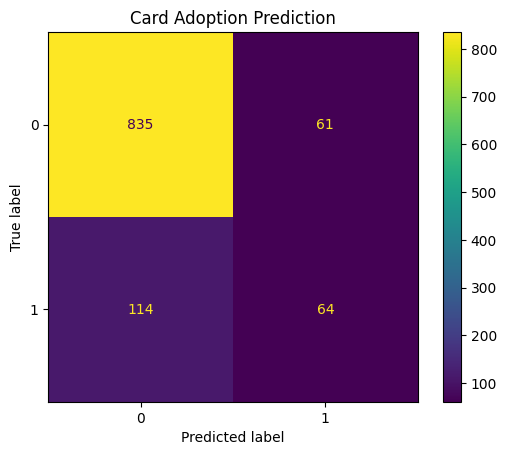

In [77]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test)

plt.title("Card Adoption Prediction")
plt.show()

### Feature Importance

In [78]:
importance = (pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})
.sort_values("Importance", ascending=False))

display(importance.head(10))

,Feature,Importance
3,Avg_Balance,0.343871
2,Total_Amount,0.215097
1,Transaction_Count,0.166874
0,age,0.148114
9,type_USER,0.057858
4,sex_Male,0.020960
6,Account_type_Savings Account,0.016897
5,Account_type_Salary Account,0.015560
7,frequency_Monthly Issuance,0.008679
8,frequency_Weekly Issuance,0.006091


## Business Insights

- Customer demographics and transaction behaviour help predict card adoption.
- Customers with higher banking activity are more likely to own a card.
- The model can identify potential customers for targeted marketing campaigns.

## Recommendations

- Prioritize customers with a high predicted probability for card offers.
- Use personalized campaigns to improve card adoption.
- Regularly retrain the model as new customer data becomes available.

In [79]:
import joblib

joblib.dump(rf, "card_adoption_model.pkl")

['card_adoption_model.pkl']

In [80]:
import joblib

joblib.dump(kmeans, "kmeans_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [81]:
joblib.dump(rf, "loan_risk_model.pkl")

['loan_risk_model.pkl']

In [82]:
joblib.dump(rf, "card_adoption_model.pkl")

['card_adoption_model.pkl']